# **TASK 05 - MODEL TRAINING AND OPTIMIZATION**

## **Imports & Environment Setup**

In [18]:
import copy
import json
import os
import pickle
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch_geometric.data import Data
from torch_geometric.utils import to_undirected

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

os.makedirs("models_checkpoints", exist_ok=True)
os.makedirs("reports", exist_ok=True)

print("Device available:", "GPU" if torch.cuda.is_available() else "CPU")


Device available: GPU


## **Load Processed OGBN-Arxiv Data**

In [23]:
DATA_PATH = "data/processed/processed_data.pkl"

with open(DATA_PATH, "rb") as file:
    processed_data = pickle.load(file)

print("Available data keys:")
print(processed_data.keys())

Available data keys:
dict_keys(['features', 'labels', 'edge_index', 'train_idx', 'valid_idx', 'test_idx'])


## **Graph Data Preparation**

In [24]:
features = processed_data["features"]
labels = processed_data["labels"].view(-1)

# OGBN-Arxiv citation links are directed. Adding reverse links allows
# both models to aggregate information in both citation directions.
edge_index = to_undirected(
    processed_data["edge_index"].long(),
    num_nodes=features.shape[0]
)

train_idx = processed_data["train_idx"].view(-1)
valid_idx = processed_data["valid_idx"].view(-1)
test_idx = processed_data["test_idx"].view(-1)

num_nodes = features.shape[0]
num_features = features.shape[1]
num_classes = int(labels.max().item()) + 1

print(f"Number of nodes: {num_nodes:,}")
print(f"Directed edges before conversion: {processed_data['edge_index'].shape[1]:,}")
print(f"Edges after bidirectional conversion: {edge_index.shape[1]:,}")
print(f"Number of features: {num_features}")
print(f"Number of classes: {num_classes}")
print(f"Training nodes: {len(train_idx):,}")
print(f"Validation nodes: {len(valid_idx):,}")
print(f"Test nodes: {len(test_idx):,}")

Number of nodes: 169,343
Directed edges before conversion: 1,166,243
Edges after bidirectional conversion: 2,315,598
Number of features: 128
Number of classes: 40
Training nodes: 90,941
Validation nodes: 29,799
Test nodes: 48,603


## **Reproducibility & Device Setup**

In [25]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

graph_data = Data(
    x=features.float(),
    edge_index=edge_index.long(),
    y=labels.long()
).to(DEVICE)

train_idx = train_idx.long().to(DEVICE)
valid_idx = valid_idx.long().to(DEVICE)
test_idx = test_idx.long().to(DEVICE)

print("Using device:", DEVICE)
print("Graph device:", graph_data.x.device)
print("Graph data prepared successfully.")


Using device: cuda
Graph device: cuda:0
Graph data prepared successfully.


## **Load Task 4 Model Configuration**

The saved configuration provides the input dimension, output classes, hidden dimension, dropout rate, and random seed selected during Task 4.

In [26]:
CONFIG_PATH = "models_checkpoints/model_config.json"

if os.path.exists(CONFIG_PATH):
    with open(CONFIG_PATH, "r") as file:
        model_config = json.load(file)
    print(f"Loaded Task 4 configuration from {CONFIG_PATH}")
else:
    # This fallback matches the configuration defined in Task 4.
    model_config = {
        "gcn": {
            "class": "GCN",
            "in_channels": num_features,
            "hidden_channels": 256,
            "out_channels": num_classes,
            "dropout": 0.5
        },
        "graphsage": {
            "class": "GraphSAGE",
            "in_channels": num_features,
            "hidden_channels": 256,
            "out_channels": num_classes,
            "dropout": 0.5
        },
        "seed": SEED
    }
    print("model_config.json was not found; using the matching Task 4 configuration.")

print("GCN configuration:")
print(model_config["gcn"])
print("\nGraphSAGE configuration:")
print(model_config["graphsage"])
print("\nRandom seed:", model_config["seed"])

gcn_config = model_config["gcn"]
sage_config = model_config["graphsage"]


model_config.json was not found; using the matching Task 4 configuration.
GCN configuration:
{'class': 'GCN', 'in_channels': 128, 'hidden_channels': 256, 'out_channels': 40, 'dropout': 0.5}

GraphSAGE configuration:
{'class': 'GraphSAGE', 'in_channels': 128, 'hidden_channels': 256, 'out_channels': 40, 'dropout': 0.5}

Random seed: 42


## **Model Architectures from Task 4**

The updated three-layer GCN and GraphSAGE architectures are imported from the shared Task 4 model module. Both models include Batch Normalization after the first two graph-convolution layers. This keeps Task 4 as the single source of truth and ensures that training and evaluation use the latest architectures.

In [27]:
from src.models.gnn_models import GCN, GraphSAGE

print("Updated Task 4 GCN and GraphSAGE architectures imported successfully.")


Updated Task 4 GCN and GraphSAGE architectures imported successfully.


## **Loss Function, Optimizer & Hyperparameter Search**


In [28]:
LOSS_FUNCTION = nn.CrossEntropyLoss()

HYPERPARAMETER_CONFIGS = [
    {
        "name": "Config 1",
        "learning_rate": 0.01,
        "hidden_channels": 256,
        "dropout": 0.5,
        "weight_decay": 0.0
    },
    {
        "name": "Config 2",
        "learning_rate": 0.005,
        "hidden_channels": 256,
        "dropout": 0.5,
        "weight_decay": 5e-4
    },
    {
        "name": "Config 3",
        "learning_rate": 0.01,
        "hidden_channels": 256,
        "dropout": 0.3,
        "weight_decay": 1e-4
    }
]

# Tuning is long enough for BatchNorm models to separate clearly.
# Final training permits up to 500 epochs but can stop earlier.
TUNING_EPOCHS = 100
FINAL_EPOCHS = 500
TUNING_PATIENCE = 25
FINAL_PATIENCE = 75

hyperparameter_table = pd.DataFrame(HYPERPARAMETER_CONFIGS)
hyperparameter_table


,name,learning_rate,hidden_channels,dropout,weight_decay
0,Config 1,0.010,256,0.5,0.0000
1,Config 2,0.005,256,0.5,0.0005
2,Config 3,0.010,256,0.3,0.0001


## **Training & Validation Utilities**

In [29]:
def calculate_accuracy(logits, labels):
    predictions = logits.argmax(dim=1)
    return (predictions == labels).float().mean().item()


def train_one_epoch(model, optimizer):
    model.train()
    optimizer.zero_grad()

    logits = model(graph_data.x, graph_data.edge_index)

    loss = LOSS_FUNCTION(
        logits[train_idx],
        graph_data.y[train_idx]
    )

    loss.backward()
    optimizer.step()

    train_accuracy = calculate_accuracy(
        logits[train_idx],
        graph_data.y[train_idx]
    )

    return loss.item(), train_accuracy


@torch.no_grad()
def validate_model(model, split_idx):
    model.eval()

    logits = model(graph_data.x, graph_data.edge_index)

    loss = LOSS_FUNCTION(
        logits[split_idx],
        graph_data.y[split_idx]
    )

    accuracy = calculate_accuracy(
        logits[split_idx],
        graph_data.y[split_idx]
    )

    return loss.item(), accuracy


print("Training and validation functions created successfully.")

Training and validation functions created successfully.


In [30]:
def train_model(
    model,
    learning_rate,
    weight_decay,
    epochs,
    patience,
    print_every=10
):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=10,
        min_lr=1e-5
    )

    training_log = []
    best_state = copy.deepcopy(model.state_dict())
    best_validation_accuracy = -1.0
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = train_one_epoch(model, optimizer)
        val_loss, val_accuracy = validate_model(model, valid_idx)
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]
        training_log.append({
            "epoch": epoch,
            "learning_rate": current_lr,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "validation_loss": val_loss,
            "validation_accuracy": val_accuracy
        })

        if val_accuracy > best_validation_accuracy:
            best_validation_accuracy = val_accuracy
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch == 1 or epoch % print_every == 0:
            print(
                f"Epoch {epoch:03d} | LR: {current_lr:.6f} | "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f} | "
                f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f}"
            )

        if epochs_without_improvement >= patience:
            print(
                f"Early stopping at epoch {epoch}. "
                f"Restoring epoch {best_epoch} with validation accuracy "
                f"{best_validation_accuracy:.4f}."
            )
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(training_log)


print("Training function with scheduling, early stopping, and best-weight restoration created.")


Training function with scheduling, early stopping, and best-weight restoration created.


## **Hyperparameter Tuning**

### **GCN Tuning Results**

In [31]:
gcn_tuning_results = []

for config in HYPERPARAMETER_CONFIGS:
    print(f"\nTraining GCN - {config['name']}")
    set_seed(SEED)

    trial_model = GCN(
        in_channels=gcn_config["in_channels"],
        hidden_channels=config["hidden_channels"],
        out_channels=gcn_config["out_channels"],
        dropout=config["dropout"]
    ).to(DEVICE)

    trained_model, log = train_model(
        model=trial_model,
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"],
        epochs=TUNING_EPOCHS,
        patience=TUNING_PATIENCE
    )

    best_row = log.loc[log["validation_accuracy"].idxmax()]
    gcn_tuning_results.append({
        "configuration": config["name"],
        "learning_rate": config["learning_rate"],
        "hidden_channels": config["hidden_channels"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],
        "best_epoch": int(best_row["epoch"]),
        "best_validation_loss": best_row["validation_loss"],
        "best_validation_accuracy": best_row["validation_accuracy"]
    })

    del trial_model, trained_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

gcn_tuning_results = pd.DataFrame(gcn_tuning_results).sort_values(
    "best_validation_accuracy", ascending=False
).reset_index(drop=True)

gcn_tuning_results



Training GCN - Config 1
Epoch 001 | LR: 0.010000 | Train Loss: 4.2089 | Train Acc: 0.0257 | Val Loss: 2.8514 | Val Acc: 0.4013
Epoch 010 | LR: 0.010000 | Train Loss: 1.3440 | Train Acc: 0.6457 | Val Loss: 1.2594 | Val Acc: 0.6531
Epoch 020 | LR: 0.010000 | Train Loss: 1.1663 | Train Acc: 0.6763 | Val Loss: 1.0885 | Val Acc: 0.6872
Epoch 030 | LR: 0.010000 | Train Loss: 1.0896 | Train Acc: 0.6894 | Val Loss: 1.0140 | Val Acc: 0.7027
Epoch 040 | LR: 0.010000 | Train Loss: 1.0476 | Train Acc: 0.6986 | Val Loss: 0.9885 | Val Acc: 0.7091
Epoch 050 | LR: 0.010000 | Train Loss: 1.0139 | Train Acc: 0.7058 | Val Loss: 0.9713 | Val Acc: 0.7111
Epoch 060 | LR: 0.010000 | Train Loss: 0.9885 | Train Acc: 0.7104 | Val Loss: 0.9591 | Val Acc: 0.7141
Epoch 070 | LR: 0.010000 | Train Loss: 0.9676 | Train Acc: 0.7144 | Val Loss: 0.9473 | Val Acc: 0.7170
Epoch 080 | LR: 0.010000 | Train Loss: 0.9480 | Train Acc: 0.7183 | Val Loss: 0.9374 | Val Acc: 0.7179
Epoch 090 | LR: 0.010000 | Train Loss: 0.9321 | 

,configuration,learning_rate,hidden_channels,dropout,weight_decay,best_epoch,best_validation_loss,best_validation_accuracy
0,Config 3,0.010,256,0.3,0.0001,96,0.927214,0.722373
1,Config 1,0.010,256,0.5,0.0000,100,0.921641,0.721266
2,Config 2,0.005,256,0.5,0.0005,100,0.997800,0.720293


In [33]:
best_gcn_name = gcn_tuning_results.iloc[0]["configuration"]
best_gcn_config = next(
    config for config in HYPERPARAMETER_CONFIGS
    if config["name"] == best_gcn_name
)

print("Best GCN configuration selected from validation results:")
print(best_gcn_config)


Best GCN configuration selected from validation results:
{'name': 'Config 3', 'learning_rate': 0.01, 'hidden_channels': 256, 'dropout': 0.3, 'weight_decay': 0.0001}


### **GraphSAGE Tuning Results**

In [34]:
sage_tuning_results = []

for config in HYPERPARAMETER_CONFIGS:
    print(f"\nTraining GraphSAGE - {config['name']}")
    set_seed(SEED)

    trial_model = GraphSAGE(
        in_channels=sage_config["in_channels"],
        hidden_channels=config["hidden_channels"],
        out_channels=sage_config["out_channels"],
        dropout=config["dropout"]
    ).to(DEVICE)

    trained_model, log = train_model(
        model=trial_model,
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"],
        epochs=TUNING_EPOCHS,
        patience=TUNING_PATIENCE
    )

    best_row = log.loc[log["validation_accuracy"].idxmax()]
    sage_tuning_results.append({
        "configuration": config["name"],
        "learning_rate": config["learning_rate"],
        "hidden_channels": config["hidden_channels"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],
        "best_epoch": int(best_row["epoch"]),
        "best_validation_loss": best_row["validation_loss"],
        "best_validation_accuracy": best_row["validation_accuracy"]
    })

    del trial_model, trained_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

sage_tuning_results = pd.DataFrame(sage_tuning_results).sort_values(
    "best_validation_accuracy", ascending=False
).reset_index(drop=True)

sage_tuning_results



Training GraphSAGE - Config 1
Epoch 001 | LR: 0.010000 | Train Loss: 3.8070 | Train Acc: 0.0306 | Val Loss: 2.3273 | Val Acc: 0.4580
Epoch 010 | LR: 0.010000 | Train Loss: 1.4640 | Train Acc: 0.6047 | Val Loss: 1.6860 | Val Acc: 0.6059
Epoch 020 | LR: 0.010000 | Train Loss: 1.2355 | Train Acc: 0.6487 | Val Loss: 1.2306 | Val Acc: 0.6405
Epoch 030 | LR: 0.010000 | Train Loss: 1.1312 | Train Acc: 0.6717 | Val Loss: 1.0749 | Val Acc: 0.6769
Epoch 040 | LR: 0.010000 | Train Loss: 1.0667 | Train Acc: 0.6846 | Val Loss: 1.0138 | Val Acc: 0.6971
Epoch 050 | LR: 0.010000 | Train Loss: 1.0239 | Train Acc: 0.6963 | Val Loss: 0.9834 | Val Acc: 0.7048
Epoch 060 | LR: 0.010000 | Train Loss: 0.9897 | Train Acc: 0.7050 | Val Loss: 0.9562 | Val Acc: 0.7086
Epoch 070 | LR: 0.010000 | Train Loss: 0.9635 | Train Acc: 0.7103 | Val Loss: 0.9393 | Val Acc: 0.7115
Epoch 080 | LR: 0.010000 | Train Loss: 0.9378 | Train Acc: 0.7168 | Val Loss: 0.9221 | Val Acc: 0.7156
Epoch 090 | LR: 0.010000 | Train Loss: 0.9

,configuration,learning_rate,hidden_channels,dropout,weight_decay,best_epoch,best_validation_loss,best_validation_accuracy
0,Config 2,0.005,256,0.5,0.0005,100,0.906777,0.719454
1,Config 3,0.010,256,0.3,0.0001,97,0.903129,0.719118
2,Config 1,0.010,256,0.5,0.0000,96,0.902569,0.718380


In [36]:
best_sage_name = sage_tuning_results.iloc[0]["configuration"]
best_sage_config = next(
    config for config in HYPERPARAMETER_CONFIGS
    if config["name"] == best_sage_name
)

print("Best GraphSAGE configuration selected from validation results:")
print(best_sage_config)


Best GraphSAGE configuration selected from validation results:
{'name': 'Config 2', 'learning_rate': 0.005, 'hidden_channels': 256, 'dropout': 0.5, 'weight_decay': 0.0005}


## **Final Model Training**

### **Final GCN Training**

In [37]:
set_seed(SEED)

gcn_model = GCN(
    in_channels=gcn_config["in_channels"],
    hidden_channels=best_gcn_config["hidden_channels"],
    out_channels=gcn_config["out_channels"],
    dropout=best_gcn_config["dropout"]
).to(DEVICE)

gcn_model, gcn_training_log = train_model(
    model=gcn_model,
    learning_rate=best_gcn_config["learning_rate"],
    weight_decay=best_gcn_config["weight_decay"],
    epochs=FINAL_EPOCHS,
    patience=FINAL_PATIENCE
)

gcn_best_row = gcn_training_log.loc[
    gcn_training_log["validation_accuracy"].idxmax()
]
print("\nGCN final training completed.")
print(f"Best epoch: {int(gcn_best_row['epoch'])}")
print(f"Best validation accuracy: {gcn_best_row['validation_accuracy']:.4f}")


Epoch 001 | LR: 0.010000 | Train Loss: 4.1802 | Train Acc: 0.0266 | Val Loss: 2.8523 | Val Acc: 0.4018
Epoch 010 | LR: 0.010000 | Train Loss: 1.2966 | Train Acc: 0.6569 | Val Loss: 1.2523 | Val Acc: 0.6548
Epoch 020 | LR: 0.010000 | Train Loss: 1.1204 | Train Acc: 0.6865 | Val Loss: 1.0813 | Val Acc: 0.6879
Epoch 030 | LR: 0.010000 | Train Loss: 1.0447 | Train Acc: 0.7000 | Val Loss: 1.0126 | Val Acc: 0.7018
Epoch 040 | LR: 0.010000 | Train Loss: 0.9993 | Train Acc: 0.7104 | Val Loss: 0.9866 | Val Acc: 0.7092
Epoch 050 | LR: 0.010000 | Train Loss: 0.9643 | Train Acc: 0.7172 | Val Loss: 0.9727 | Val Acc: 0.7128
Epoch 060 | LR: 0.010000 | Train Loss: 0.9367 | Train Acc: 0.7227 | Val Loss: 0.9598 | Val Acc: 0.7148
Epoch 070 | LR: 0.010000 | Train Loss: 0.9115 | Train Acc: 0.7269 | Val Loss: 0.9521 | Val Acc: 0.7175
Epoch 080 | LR: 0.010000 | Train Loss: 0.8868 | Train Acc: 0.7330 | Val Loss: 0.9386 | Val Acc: 0.7191
Epoch 090 | LR: 0.010000 | Train Loss: 0.8646 | Train Acc: 0.7385 | Val L

### **Final GraphSAGE Training**

In [38]:
set_seed(SEED)

sage_model = GraphSAGE(
    in_channels=sage_config["in_channels"],
    hidden_channels=best_sage_config["hidden_channels"],
    out_channels=sage_config["out_channels"],
    dropout=best_sage_config["dropout"]
).to(DEVICE)

sage_model, sage_training_log = train_model(
    model=sage_model,
    learning_rate=best_sage_config["learning_rate"],
    weight_decay=best_sage_config["weight_decay"],
    epochs=FINAL_EPOCHS,
    patience=FINAL_PATIENCE
)

sage_best_row = sage_training_log.loc[
    sage_training_log["validation_accuracy"].idxmax()
]
print("\nGraphSAGE final training completed.")
print(f"Best epoch: {int(sage_best_row['epoch'])}")
print(f"Best validation accuracy: {sage_best_row['validation_accuracy']:.4f}")


Epoch 001 | LR: 0.005000 | Train Loss: 3.8070 | Train Acc: 0.0306 | Val Loss: 2.8432 | Val Acc: 0.4549
Epoch 010 | LR: 0.005000 | Train Loss: 1.4312 | Train Acc: 0.6136 | Val Loss: 1.4034 | Val Acc: 0.6096
Epoch 020 | LR: 0.005000 | Train Loss: 1.2061 | Train Acc: 0.6556 | Val Loss: 1.1597 | Val Acc: 0.6575
Epoch 030 | LR: 0.005000 | Train Loss: 1.1092 | Train Acc: 0.6763 | Val Loss: 1.0547 | Val Acc: 0.6885
Epoch 040 | LR: 0.005000 | Train Loss: 1.0439 | Train Acc: 0.6921 | Val Loss: 1.0173 | Val Acc: 0.7020
Epoch 050 | LR: 0.005000 | Train Loss: 0.9984 | Train Acc: 0.7029 | Val Loss: 0.9908 | Val Acc: 0.7028
Epoch 060 | LR: 0.005000 | Train Loss: 0.9610 | Train Acc: 0.7131 | Val Loss: 0.9868 | Val Acc: 0.7010
Epoch 070 | LR: 0.002500 | Train Loss: 0.9343 | Train Acc: 0.7174 | Val Loss: 0.9591 | Val Acc: 0.7055
Epoch 080 | LR: 0.002500 | Train Loss: 0.9173 | Train Acc: 0.7221 | Val Loss: 0.9317 | Val Acc: 0.7137
Epoch 090 | LR: 0.002500 | Train Loss: 0.8993 | Train Acc: 0.7264 | Val L

## **Training Performance Monitoring**

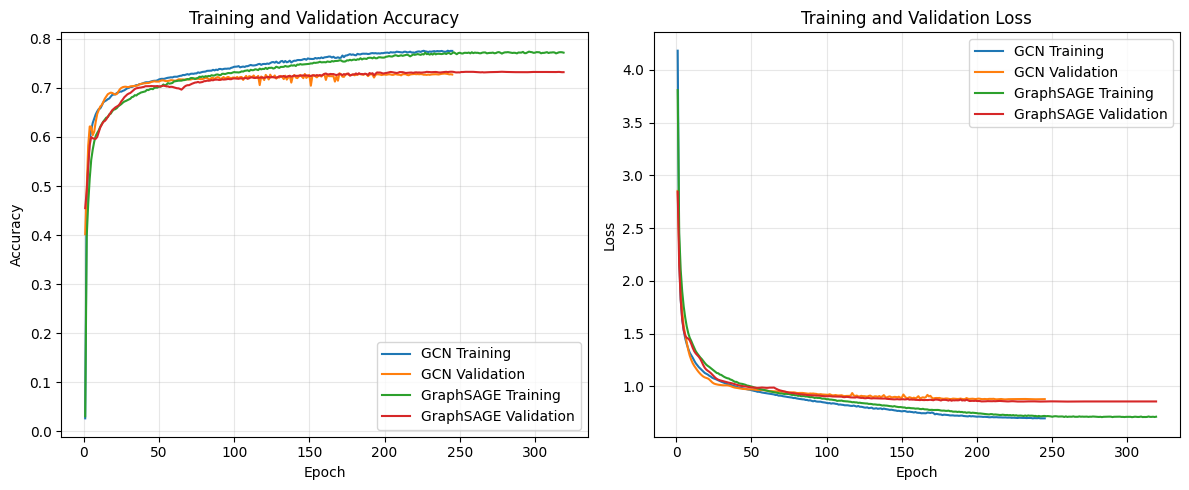

In [39]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(
    gcn_training_log["epoch"],
    gcn_training_log["train_accuracy"],
    label="GCN Training"
)
plt.plot(
    gcn_training_log["epoch"],
    gcn_training_log["validation_accuracy"],
    label="GCN Validation"
)
plt.plot(
    sage_training_log["epoch"],
    sage_training_log["train_accuracy"],
    label="GraphSAGE Training"
)
plt.plot(
    sage_training_log["epoch"],
    sage_training_log["validation_accuracy"],
    label="GraphSAGE Validation"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(
    gcn_training_log["epoch"],
    gcn_training_log["train_loss"],
    label="GCN Training"
)
plt.plot(
    gcn_training_log["epoch"],
    gcn_training_log["validation_loss"],
    label="GCN Validation"
)
plt.plot(
    sage_training_log["epoch"],
    sage_training_log["train_loss"],
    label="GraphSAGE Training"
)
plt.plot(
    sage_training_log["epoch"],
    sage_training_log["validation_loss"],
    label="GraphSAGE Validation"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("reports/training_performance.png", dpi=300)
plt.show()

## **Save Trained Models & Training Results**

In [40]:
torch.save(
    gcn_model.state_dict(),
    "models_checkpoints/gcn_final.pt"
)

torch.save(
    sage_model.state_dict(),
    "models_checkpoints/graphsage_final.pt"
)

gcn_training_log.to_csv(
    "reports/gcn_training_log.csv",
    index=False
)

sage_training_log.to_csv(
    "reports/graphsage_training_log.csv",
    index=False
)

gcn_tuning_results.to_csv(
    "reports/gcn_optimization_results.csv",
    index=False
)

sage_tuning_results.to_csv(
    "reports/graphsage_optimization_results.csv",
    index=False
)

print("Model checkpoints and Task 5 results saved successfully.")

Model checkpoints and Task 5 results saved successfully.


## **Task 5 Summary**

- Both GCN and GraphSAGE are trained using cross-entropy loss and the Adam optimizer.
- Three hyperparameter configurations are compared independently for each model.
- Batch Normalization from the updated Task 4 architectures stabilizes hidden representations.
- Bidirectional citation edges allow information aggregation in both citation directions.
- A validation-loss scheduler reduces the learning rate when progress slows.
- Early stopping limits overfitting, while the best validation weights are restored before evaluation.
- The executed tuning tables and training logs provide the final optimization results.

# **TASK 06 - MODEL EVALUATION**

Both trained models are evaluated on the validation and test sets using accuracy, macro precision, macro recall, and macro F1-score.

## **Evaluation Metrics**

In [41]:
@torch.no_grad()
def evaluate_model(model, split_idx):
    model.eval()

    logits = model(graph_data.x, graph_data.edge_index)
    predictions = logits[split_idx].argmax(dim=1).cpu().numpy()
    true_labels = graph_data.y[split_idx].cpu().numpy()

    return {
        "Accuracy": accuracy_score(true_labels, predictions),
        "Precision": precision_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Recall": recall_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "F1 Score": f1_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        )
    }


print("Evaluation function created successfully.")

Evaluation function created successfully.


## **Validation & Test Set Results**

In [42]:
evaluation_results = []

for model_name, model in [
    ("GCN", gcn_model),
    ("GraphSAGE", sage_model)
]:
    for split_name, split_idx in [
        ("Validation", valid_idx),
        ("Test", test_idx)
    ]:
        metrics = evaluate_model(model, split_idx)

        evaluation_results.append({
            "Model": model_name,
            "Dataset": split_name,
            **metrics
        })

evaluation_results = pd.DataFrame(evaluation_results)

evaluation_results[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
] = evaluation_results[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].round(4)

evaluation_results

,Model,Dataset,Accuracy,Precision,Recall,F1 Score
0,GCN,Validation,0.7299,0.6191,0.5199,0.5437
1,GCN,Test,0.7171,0.5798,0.4947,0.5142
2,GraphSAGE,Validation,0.7329,0.6152,0.5229,0.5441
3,GraphSAGE,Test,0.7191,0.5971,0.5020,0.5170


## **Model Performance Comparison**

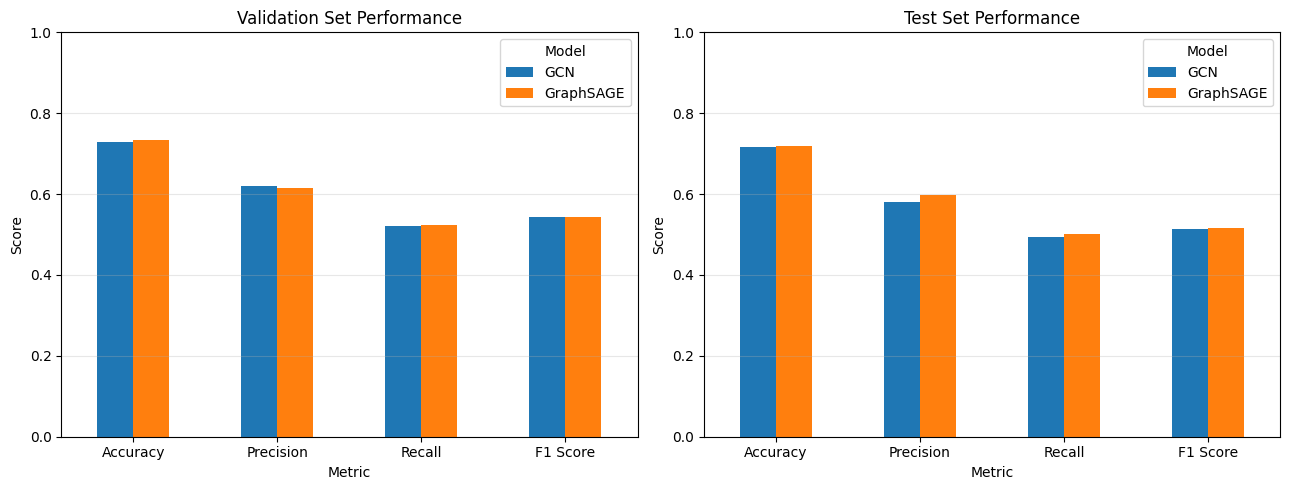

In [43]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for axis, dataset_name in zip(axes, ["Validation", "Test"]):
    subset = evaluation_results[
        evaluation_results["Dataset"] == dataset_name
    ].set_index("Model")

    subset[metrics].T.plot(kind="bar", ax=axis)
    axis.set_title(f"{dataset_name} Set Performance")
    axis.set_xlabel("Metric")
    axis.set_ylabel("Score")
    axis.set_ylim(0, 1.0)
    axis.tick_params(axis="x", rotation=0)
    axis.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("reports/model_evaluation_comparison.png", dpi=300)
plt.show()


## **Strengths, Weaknesses & Model Comparison**

In [44]:
def get_result(model_name, dataset_name):
    return evaluation_results[
        (evaluation_results["Model"] == model_name) &
        (evaluation_results["Dataset"] == dataset_name)
    ].iloc[0]

gcn_val = get_result("GCN", "Validation")
gcn_test = get_result("GCN", "Test")

print(
    f"GCN achieved {gcn_val['Accuracy']:.2%} validation accuracy and "
    f"{gcn_test['Accuracy']:.2%} test accuracy. Its main strength is "
    f"stable full-graph aggregation with Batch Normalization. On the test "
    f"set, macro precision was {gcn_test['Precision']:.2%}, macro recall was "
    f"{gcn_test['Recall']:.2%}, and macro F1-score was "
    f"{gcn_test['F1 Score']:.2%}. A validation-to-test accuracy reduction of "
    f"{(gcn_val['Accuracy'] - gcn_test['Accuracy']):.2%} indicates its "
    f"remaining generalization weakness."
)


GCN achieved 72.99% validation accuracy and 71.71% test accuracy. Its main strength is stable full-graph aggregation with Batch Normalization. On the test set, macro precision was 57.98%, macro recall was 49.47%, and macro F1-score was 51.42%. A validation-to-test accuracy reduction of 1.28% indicates its remaining generalization weakness.


In [45]:
sage_val = get_result("GraphSAGE", "Validation")
sage_test = get_result("GraphSAGE", "Test")

print(
    f"GraphSAGE achieved {sage_val['Accuracy']:.2%} validation accuracy and "
    f"{sage_test['Accuracy']:.2%} test accuracy. Its learned neighbourhood "
    f"aggregation is a strength for capturing citation-network patterns. On "
    f"the test set, macro precision was {sage_test['Precision']:.2%}, macro "
    f"recall was {sage_test['Recall']:.2%}, and macro F1-score was "
    f"{sage_test['F1 Score']:.2%}. A validation-to-test accuracy reduction of "
    f"{(sage_val['Accuracy'] - sage_test['Accuracy']):.2%} represents its "
    f"remaining generalization weakness."
)


GraphSAGE achieved 73.29% validation accuracy and 71.91% test accuracy. Its learned neighbourhood aggregation is a strength for capturing citation-network patterns. On the test set, macro precision was 59.71%, macro recall was 50.20%, and macro F1-score was 51.70%. A validation-to-test accuracy reduction of 1.38% represents its remaining generalization weakness.


In [46]:
test_results = evaluation_results[
    evaluation_results["Dataset"] == "Test"
].set_index("Model")

best_accuracy_model = test_results["Accuracy"].idxmax()
best_f1_model = test_results["F1 Score"].idxmax()
accuracy_gap = abs(
    test_results.loc["GraphSAGE", "Accuracy"] -
    test_results.loc["GCN", "Accuracy"]
)

print(
    f"{best_accuracy_model} achieved the higher test accuracy, with an "
    f"absolute difference of {accuracy_gap:.2%} between the two models. "
    f"{best_f1_model} achieved the higher macro F1-score. Accuracy measures "
    f"overall correctness, while macro precision, recall, and F1 give equal "
    f"importance to all 40 classes. Therefore, the final model should be "
    f"selected using both test accuracy and macro F1-score rather than "
    f"accuracy alone."
)


GraphSAGE achieved the higher test accuracy, with an absolute difference of 0.20% between the two models. GraphSAGE achieved the higher macro F1-score. Accuracy measures overall correctness, while macro precision, recall, and F1 give equal importance to all 40 classes. Therefore, the final model should be selected using both test accuracy and macro F1-score rather than accuracy alone.


## **Save Evaluation Results**

In [47]:
evaluation_results.to_csv(
    "reports/model_evaluation_results.csv",
    index=False
)

print("Task 6 evaluation results saved successfully.")

Task 6 evaluation results saved successfully.


In [48]:
validation_results = evaluation_results[
    evaluation_results["Dataset"] == "Validation"
].set_index("Model")
test_results = evaluation_results[
    evaluation_results["Dataset"] == "Test"
].set_index("Model")

summary = pd.DataFrame({
    "Best Validation Accuracy": validation_results["Accuracy"],
    "Test Accuracy": test_results["Accuracy"],
    "Test Macro Precision": test_results["Precision"],
    "Test Macro Recall": test_results["Recall"],
    "Test Macro F1": test_results["F1 Score"]
}).round(4)

print("Task 6 summary:")
display(summary)
print("Best model by test accuracy:", test_results["Accuracy"].idxmax())
print("Best model by test macro F1:", test_results["F1 Score"].idxmax())


Task 6 summary:


,Best Validation Accuracy,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1
Model,,,,,
GCN,0.7299,0.7171,0.5798,0.4947,0.5142
GraphSAGE,0.7329,0.7191,0.5971,0.5020,0.5170


Best model by test accuracy: GraphSAGE
Best model by test macro F1: GraphSAGE
